# TwoTank — Stage 2 — Sparse Dictionary Policy Training (DPC)

Train and inspect the sparse SD-DPC policy.


## 1. Set up the system and load the stage config

Load dependencies and configuration.


In [1]:
"""Boilerplate: make the in-repo `sdpc` package importable and resolve this system."""
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_p = Path.cwd()
while not (_p / "src" / "sdpc").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import torch
from sdpc.config import load_config
from sdpc.registry import make_system

SYSTEM = "twotank"
device = torch.device("cpu")
system = make_system(SYSTEM, device=device)
CONFIGS = Path.cwd().parent / "configs"
RESULTS = Path.cwd().parent / "results"

print(f"System        : {SYSTEM}")
print(f"State dim nx  : {system.nx}")
print(f"Control dim nu: {system.nu}")
print(f"Sample time ts: {system.ts}")
print(f"Input bounds  : [{system.umin}, {system.umax}]")
print(f"State bounds  : [{system.xmin}, {system.xmax}]")
print(f"Discrete model: {system.is_discrete}")


System        : twotank
State dim nx  : 2
Control dim nu: 2
Sample time ts: 1.0
Input bounds  : [0.0, 1.0]
State bounds  : [0.0, 1.0]
Discrete model: False


In [2]:
cfg = load_config(CONFIGS / 'policy.yaml')
cfg['epochs'] = 3000  # reduced for interactive use; remove this line for the full run

print('Resolved policy-training config:')
for k, v in cfg.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')

Resolved policy-training config:
  seed: 0
  policy_seed: 0
  action_scale: 1.0
  action_gradient_mode: leaky_straight_through
  action_gradient_band: 0.05
  action_gradient_leak: 0.01
  nsteps: 50
  n_samples: 2000
  batch_size: 200
  seed_data: 5
  eval_seed: 0
  eval_margin: 0.1
  lr: 0.005
  grad_clip: 5.0
  proximal_l1: False
  epochs: 3000
  threshold: 0.2
  prune_every: 200
  prune_every_min: 200
  prune_every_decay: 50
  change_prune_every: False
  threshold_mult: 1.1
  threshold_max: 0.3
  prune_noise: 0.0
  lr_decay_enabled: True
  lr_decay_gamma: 0.97
  lr_decay_step: 100
  l1_decay: 1.0
  warmup: 100
  patience: 50
  verbosity: 1
  logger_metrics: ['train_loss', 'dev_loss', 'train_tracking_loss', 'dev_tracking_loss', 'train_l1_loss', 'dev_l1_loss', 'train_constraint_loss', 'dev_constraint_loss', 'learning_rate']
  weights: {'Q_r': 20.0, 'Q_u': 0.0, 'Q_dx': 0.0, 'Q_du': 0.0, 'Q_con': 20.0, 'l1_coef': 0.1}


## 2. Load the identified dynamics model from Stage 1

Restore the required checkpoints.


In [3]:
from sdpc.sindy import load_model

dyn_runs = sorted((RESULTS / 'models' / 'dynamics').glob('run_*'))
assert dyn_runs, 'no SINDy dynamics runs found — run 01_system_id.ipynb first'
print('Using dynamics checkpoint:', dyn_runs[-1])

sindy = load_model(dyn_runs[-1] / 'saved_models' / 'sindy.pt', device=device)
print('\nLoaded dynamics model:')
sindy.pretty_print()

Using dynamics checkpoint: /Users/alireza/Documents/PythonProject/gptSparseDPC/SparseDPC/6_Relative_Degree_One/TwoTank/results/models/dynamics/run_1

Loaded dynamics model:
dx0/dt = +7.9942e-02·u0 + -3.9976e-02·sqrt(x0) + -7.9905e-02·u0*u1
dx1/dt = +3.9981e-02·sqrt(x0) + -3.9980e-02·sqrt(x1) + +7.9943e-02·u0*u1


## 3. Build the sparse policy library and model

Define the system and problem.


In [4]:
from sdpc.sindy import CompiledFunctionLibrary, SINDyVectorized

policy_lib_cfg = system.policy_library_cfg()
print('Policy library config:', policy_lib_cfg)

plib = CompiledFunctionLibrary(**policy_lib_cfg)
policy = SINDyVectorized(
    library=plib, n_out=system.nu,
    policy_name=[f'u{i}' for i in range(system.nu)],
    device=device, seed=cfg.get('policy_seed', 0),
)
init_scale = cfg.get('init_scale')
if init_scale is not None:
    for i in range(system.nu):
        policy.Xi[i].data.mul_(init_scale)

print(f'\nPolicy library has {plib.shape[0]} candidate terms:')
print(plib.function_names)
print('\nInitial (untrained) policy:')
policy.pretty_print()

Policy library config: {'n_features': 2, 'n_control': 1, 'is_policy': True, 'include_bias': False, 'max_degree': 2, 'add_sqrt': True, 'add_xu': True, 'add_u_prod': True, 'add_fourier': True, 'max_freq': 2}

Policy library has 22 candidate terms:
['x0', 'x1', 'r0', 'sqrt(x0)', 'sqrt(x1)', 'x0^2', 'x0*x1', 'x1^2', 'x0*r0', 'x1*r0', 'sin(1·x0)', 'sin(2·x0)', 'sin(1·x1)', 'sin(2·x1)', 'cos(1·x0)', 'cos(2·x0)', 'cos(1·x1)', 'cos(2·x1)', 'sin(1·r0)', 'sin(2·r0)', 'cos(1·r0)', 'cos(2·r0)']

Initial (untrained) policy:
u0 = -3.7434e-04·x0 + +2.6822e-02·x1 + -4.1152e-02·r0 + -3.6797e-02·sqrt(x0) + -1.9258e-02·sqrt(x1) + +1.3408e-02·x0^2 + -9.9066e-04·x0*x1 + +3.9644e-02·x1^2 + -4.4372e-03·x0*r0 + +1.3231e-02·x1*r0 + -1.5111e-02·sin(1·x0) + -9.8283e-03·sin(2·x0) + -4.7767e-02·sin(1·x1) + -3.3114e-02·sin(2·x1) + -2.0611e-02·cos(1·x0) + +1.8522e-03·cos(2·x0) + +1.9767e-02·cos(1·x1) + +3.0001e-02·cos(2·x1) + -3.3897e-02·sin(1·r0) + -2.1773e-02·sin(2·r0) + +1.8161e-02·cos(1·r0) + +4.1519e-02·cos(2·r

## 4. Generate policy-training data

Prepare the required training data.


In [5]:
train_loader, dev_loader = system.make_policy_data(cfg, device)

batch = next(iter(train_loader))
print('Train batch keys:', list(batch.keys()))
print('xn shape (batch, 1, nx):', tuple(batch['xn'].shape))
print('r  shape (batch, horizon+1, nref):', tuple(batch['r'].shape))

Train batch keys: ['xn', 'r', 'x0_n', 'r0', 'x1_n', 'r1', 'name']
xn shape (batch, 1, nx): (200, 1, 2)
r  shape (batch, horizon+1, nref): (200, 51, 2)


## 5. Train the sparse policy (differentiable predictive control)

Optimize the controller parameters.


In [6]:
from sdpc.training import train_policy
from sdpc.io import CustomLogger

logger = CustomLogger(args=None, savedir=str(RESULTS / 'logs' / 'policy_nb'),
                      verbosity= cfg['verbosity'],
                      stdout=['train_loss', 'dev_loss'])
train_policy(system, sindy, policy, train_loader, dev_loader, cfg, device,
             logger=logger, action_scale=cfg.get('action_scale', 1.0))

None
epoch: 0	train_loss: 1.087e+01	train_tracking_loss: 3.437e+00	train_l1_loss: 9.522e-02	train_constraint_loss: 7.336e+00	learning_rate: 5.000e-03	dev_loss: 8.347e+00	dev_tracking_loss: 2.570e+00	dev_l1_loss: 1.072e-01	dev_constraint_loss: 5.669e+00	eltime:  0.86924
epoch: 1	train_loss: 6.899e+00	train_tracking_loss: 2.120e+00	train_l1_loss: 1.006e-01	train_constraint_loss: 4.679e+00	learning_rate: 5.000e-03	dev_loss: 5.511e+00	dev_tracking_loss: 1.769e+00	dev_l1_loss: 9.274e-02	dev_constraint_loss: 3.649e+00	eltime:  1.65453
epoch: 2	train_loss: 4.618e+00	train_tracking_loss: 1.532e+00	train_l1_loss: 1.031e-01	train_constraint_loss: 2.983e+00	learning_rate: 5.000e-03	dev_loss: 3.579e+00	dev_tracking_loss: 1.359e+00	dev_l1_loss: 1.182e-01	dev_constraint_loss: 2.102e+00	eltime:  2.39869
epoch: 3	train_loss: 3.015e+00	train_tracking_loss: 1.206e+00	train_l1_loss: 1.352e-01	train_constraint_loss: 1.674e+00	learning_rate: 5.000e-03	dev_loss: 2.498e+00	dev_tracking_loss: 1.124e+00	dev_l1

{}

## 6. Inspect the learned policy

Inspect policy performance.


In [7]:
print('Learned sparse policy:')
policy.pretty_print()
print()
print('Active terms per output:', [len(idx) for idx in policy.active_idx])
print('Total active terms      :', sum(len(idx) for idx in policy.active_idx))

Learned sparse policy:
u0 = +5.6864e-01·r0 + +5.0998e-01·cos(2·x0) + +6.1887e-01·cos(2·x1) + -1.0100e+00·cos(2·r0)
u1 = -5.1938e-01·cos(2·x0) + +4.8785e-01·cos(2·x1)

Active terms per output: [4, 2]
Total active terms      : 6


## 7. Visualize the active coefficients

Inspect the surviving coefficients.


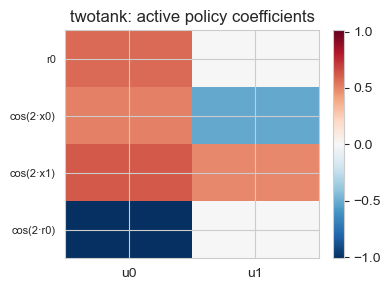

In [8]:
from sdpc.plotting import plot_coef_heatmap
import matplotlib.pyplot as plt

plot_coef_heatmap(policy, title=f'{SYSTEM}: active policy coefficients')
plt.show()

## 8. Sanity-check a nominal closed-loop rollout

Visualize the closed-loop response.


In [9]:
from sdpc.eval import make_test_data, rollout_closed_loop

nominal_plant = system.discrete_step(sindy)
eval_seed = cfg.get('eval_seed', 2)
eval_margin = cfg.get('eval_margin', 0.1)
generator = torch.Generator(device='cpu').manual_seed(eval_seed)
span = system.xmax - system.xmin
sample_min = system.xmin + eval_margin * span
sample_span = (1.0 - 2.0 * eval_margin) * span
x0 = (sample_min + sample_span * torch.rand(system.nx, generator=generator)).tolist()
ref_level = (sample_min + sample_span * torch.rand(1, generator=generator)).item()
ref = [ref_level] * system.nx
data = make_test_data(system.nx, 60, x0, ref, device=device)

res = rollout_closed_loop(policy, nominal_plant, data,
                          umin=system.umin, umax=system.umax,
                          action_scale=cfg.get('action_scale', 1.0))
print('evaluation seed:', eval_seed)
print('x0:', data['xn'][0, 0].tolist())
print('reference:', data['r'][0, 0].tolist())
print('final state:', res['x_traj'][0, -1].tolist())

evaluation seed: 0
x0: [0.49700528383255005, 0.7145774960517883]
reference: [0.1707819402217865, 0.1707819402217865]
final state: [0.15196239948272705, 0.1639803647994995]


## 9. Save the policy (optional)

Prefer `scripts/TwoTank/train_sd_dpc.py` for a tracked run; to save directly from this notebook, uncomment below.

In [11]:
from sdpc.io import new_policy_run_dir, snapshot_config
from sdpc.sindy import save_model
run_dir = new_policy_run_dir(RESULTS, 'sparse')
save_model(policy, run_dir / 'saved_models' / 'policy_sparse.pt')
snapshot_config(run_dir, cfg)
print('Saved to', run_dir)

Saved to /Users/alireza/Documents/PythonProject/gptSparseDPC/SparseDPC/6_Relative_Degree_One/TwoTank/results/models/policies/sd_dpc/run_1
